# 03 — Extended Voltage-Grid: RF vs GRU vs CNN-GRU

## Motivation

Notebook 02 ran RF / LSTM / CNN-LSTM on the extended Tier-1 dataset.  
This notebook is the **GRU counterpart**: same data, same CV protocol, same RF baseline —  
only the recurrent cell changes (GRU vs LSTM) so the two can be compared directly.

GRU uses 3 gates instead of LSTM's 4 (no separate cell state), giving fewer params per hidden unit.  
Hidden size is raised to 47 (GRU) vs 40 (LSTM) to roughly match total parameter counts:

| Model | Hidden | Params |
|---|---|---|
| LSTM | 40 | ~14.6k |
| **GRU** | **47** | **~14.9k** |
| CNN-LSTM | 40 | ~16.3k |
| **CNN-GRU** | **47** | **~16.4k** |

## Target

`y = capacity_ahr / c_nominal_ah` — fractional SOH (= Ct / C₀). EOL at 0.8.

## Models

| Model | Input | Notes |
|---|---|---|
| **RF** | 11 charge-curve scalar descriptors | computed from (X, mask) via `vg_scalar_features` |
| **GRU** | (n_grid, 3) voltage-grid tensor | `VGGRUReg(n_features=3, hidden=47, dropout=0.35)` |
| **CNN-GRU** | (n_grid, 3) voltage-grid tensor | `VGCNNGRU(n_features=3, cnn_ch=8, hidden=47, dropout=0.35)` |

## Validation

- **GroupKFold-6** (headline): whole-cell folds, ~3 cells held out per fold across all 23 cells.
- **Leave-One-Dataset-Out (LODO)**: hold out entire NASA set (test on NASA, train on CALCE) and vice versa.

## Experiments

1. RF baseline — GroupKFold-6
2. GRU — GroupKFold-6
3. CNN-GRU — GroupKFold-6
4. GroupKFold-6 comparison table
5. LODO — all three models
6. LODO comparison table

## Setup

In [1]:
import sys
from pathlib import Path
from importlib import reload

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.model_selection import GroupKFold, LeaveOneGroupOut

# Find project root (cross-platform, works from any directory in the project)
def find_project_root(start_path=None):
    """Find the project root by looking for marker files."""
    if start_path is None:
        start_path = Path.cwd()
    else:
        start_path = Path(start_path)
    
    for marker in ['.git', 'pyproject.toml', 'CLAUDE.md', '.claude']:
        for p in [start_path] + list(start_path.parents):
            if (p / marker).exists():
                return p
    
    raise RuntimeError(f"Could not find project root (looked for .git, pyproject.toml, etc.)")

ROOT = find_project_root()
sys.path.insert(0, str(ROOT))

import src.voltage_grid as vg
import src.vg_extended as vgx
import src.vg_models

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Device selection: MPS (Apple Silicon) → CUDA → CPU
if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")
print(f"Device: {DEVICE}")

# Paths
RESULTS = ROOT / "results" / "extended_tier1"
RESULTS.mkdir(parents=True, exist_ok=True)
CACHE = ROOT / "data" / "processed" / "vg_extended_tier1.npz"

# Training hyperparameters (match nb02 / nb09)
EPOCHS     = 300
PATIENCE   = 50
BATCH_SIZE = 64
LR         = 1e-3

print(f"Cache:   {CACHE}")
print(f"Results: {RESULTS}")

Device: cuda
Cache:   c:\dev\ml-project\data\processed\vg_extended_tier1.npz
Results: c:\dev\ml-project\results\extended_tier1


## Load extended dataset

In [2]:
X, mask, y, groups, cidx, ds_groups = vgx.load_npz_ext(CACHE)

print(f"X:         {X.shape}  float32")
print(f"mask:      {mask.shape}  bool")
print(f"y:         {y.shape}  [{y.min():.3f}, {y.max():.3f}]")
print(f"groups:    {len(set(groups))} unique cells")
print(f"ds_groups: {dict(zip(*np.unique(ds_groups, return_counts=True)))}")

X:         (12260, 128, 3)  float32
mask:      (12260, 128)  bool
y:         (12260,)  [0.200, 1.242]
groups:    22 unique cells
ds_groups: {'calce': np.int64(11516), 'nasa': np.int64(744)}


In [3]:
# Map battery IDs to study groups (protocol-based)
study_group_map = {
    # NASA
    "B0005": "NASA_CTRL",
    "B0006": "NASA_CTRL",
    "B0007": "NASA_CTRL",
    "B0018": "NASA_CTRL",
    "RW1": "NASA_RW",
    "RW9": "NASA_RW",
    "RW13": "NASA_RW",
    "RW14": "NASA_RW",
    "RW15": "NASA_RW",
    "RW16": "NASA_RW",
    "RW17": "NASA_RW",
    "RW19": "NASA_RW",
    "RW20": "NASA_RW",
    # CALCE CS2 Type 1 (0.5C)
    "CS2_8": "CALCE_CS2_T1",
    "CS2_21": "CALCE_CS2_T1",
    "CS2_33": "CALCE_CS2_T1",
    "CS2_34": "CALCE_CS2_T1",
    # CALCE CS2 Type 2 (1C)
    "CS2_35": "CALCE_CS2_T2",
    "CS2_36": "CALCE_CS2_T2",
    "CS2_37": "CALCE_CS2_T2",
    "CS2_38": "CALCE_CS2_T2",
    # CALCE CS2 Type 3 (variable discharge)
    "CS2_3": "CALCE_CS2_T3",
    "CS2_9": "CALCE_CS2_T3",
    # CALCE CX2 Type 1 (0.5C)
    "CX2_16": "CALCE_CX2_T1",
    "CX2_31": "CALCE_CX2_T1",
    "CX2_33": "CALCE_CX2_T1",
    "CX2_35": "CALCE_CX2_T1",
    # CALCE CX2 Type 2 (1C)
    "CX2_34": "CALCE_CX2_T2",
    "CX2_36": "CALCE_CX2_T2",
    "CX2_37": "CALCE_CX2_T2",
    "CX2_38": "CALCE_CX2_T2",
    # CALCE CX2 Type 3 (3C discharge)
    "CX2_8": "CALCE_CX2_T3",
}

# Create study_groups array aligned with groups (battery_id)
study_groups = np.array([study_group_map.get(bid, "unknown") for bid in groups])

print(f"Study groups defined: {sorted(set(study_groups))}")
print(f"Samples per study group:")
for sg in sorted(set(study_groups)):
    count = (study_groups == sg).sum()
    print(f"  {sg:30s}: {count:5d} samples")

Study groups defined: [np.str_('CALCE_CS2_T1'), np.str_('CALCE_CS2_T2'), np.str_('CALCE_CX2_T1'), np.str_('CALCE_CX2_T2'), np.str_('NASA_CTRL'), np.str_('NASA_RW')]
Samples per study group:
  CALCE_CS2_T1                  :  1478 samples
  CALCE_CS2_T2                  :  3678 samples
  CALCE_CX2_T1                  :  3321 samples
  CALCE_CX2_T2                  :  3039 samples
  NASA_CTRL                     :   629 samples
  NASA_RW                       :   115 samples


## Coverage & sanity diagnostics

In [4]:
# Per-cell mean coverage
for ds in np.unique(ds_groups):
    sel = ds_groups == ds
    cov = mask[sel].mean(axis=1).mean()
    print(f"  {ds:10s}  {sel.sum():5d} samples   mean coverage = {cov:.3f}")

coverage_per_sample = mask.mean(axis=1)
assert coverage_per_sample.min() > 0,     "Some samples have zero coverage!"
assert y.min() >= 0.2,                    f"y.min()={y.min():.3f} unexpectedly low"
assert y.max() <= 1.5,                    f"y.max()={y.max():.3f} unexpectedly high"

# Note: skipping strict leading-block check since some samples may have sparse coverage
# The mask semantics are: True = valid grid point, False = invalid/padded
# Gaps are acceptable for cells with variable coverage across the charge protocol

print("\nAll sanity checks passed.")

  calce       11516 samples   mean coverage = 0.977
  nasa          744 samples   mean coverage = 0.960

All sanity checks passed.


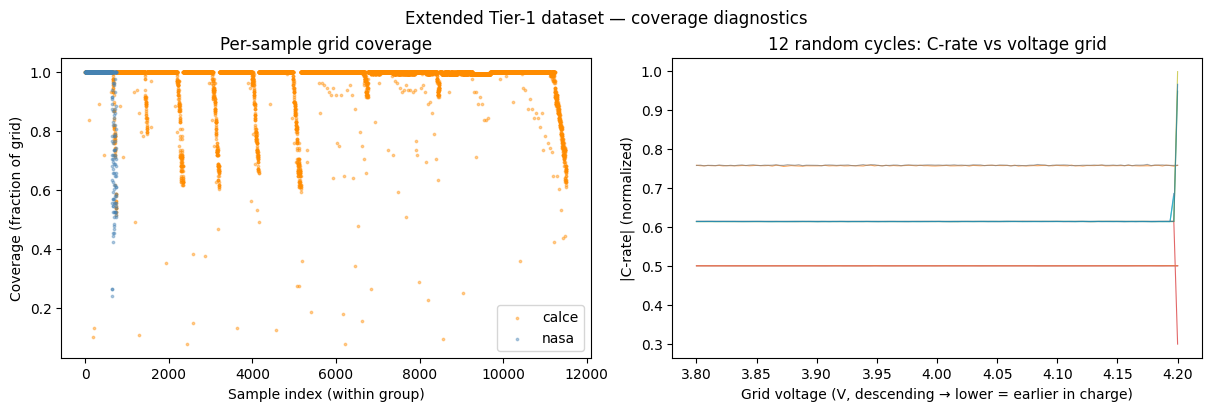

Saved: c:\dev\ml-project\results\extended_tier1\03_gru_coverage_diag.png


In [5]:
# Coverage scatter + sample C-rate curves
vgrid = np.linspace(vg.V_HI, vg.V_LO, vg.N_GRID)  # descending

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

ds_color = {"nasa": "steelblue", "calce": "darkorange"}
for ds in np.unique(ds_groups):
    sel = ds_groups == ds
    cov = mask[sel].mean(axis=1)
    ax1.scatter(np.arange(sel.sum()), cov, s=3, alpha=0.4,
                label=ds, color=ds_color.get(ds, "gray"))
ax1.set_xlabel("Sample index (within group)")
ax1.set_ylabel("Coverage (fraction of grid)")
ax1.set_title("Per-sample grid coverage")
ax1.legend()

rng = np.random.default_rng(0)
sample_ids = rng.choice(len(X), size=12, replace=False)
for si in sample_ids:
    m = mask[si]
    ax2.plot(vgrid[m], X[si, m, 0], lw=0.8, alpha=0.7)
ax2.set_xlabel("Grid voltage (V, descending \u2192 lower = earlier in charge)")
ax2.set_ylabel("|C-rate| (normalized)")
ax2.set_title("12 random cycles: C-rate vs voltage grid")

fig.suptitle("Extended Tier-1 dataset \u2014 coverage diagnostics", fontsize=12)
fig.savefig(RESULTS / "03_gru_coverage_diag.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"Saved: {RESULTS / '03_gru_coverage_diag.png'}")

## RF baseline (charge-curve scalar features)

Same RF as in notebook 02 — included here so this notebook is self-contained  
and the comparison table uses results from the same run.

| Feature | Description |
|---|---|
| `coverage` | fraction of 128-pt grid covered |
| `v_start` | voltage at CC onset (lowest covered grid V) |
| `cc_dt` | CC phase duration (s) = t_elapsed at V_HI |
| `cc_slope` | avg voltage rise rate V/s = (V_HI − v_start) / cc_dt |
| `crate_mean/max/start` | C-rate statistics over valid grid positions |
| `temp_mean/max` | temperature statistics (°C) |
| `t_total` | alias of cc_dt |
| `r_proxy` | charge-side ohmic proxy: k×ΔV_step / crate_start |

In [6]:
feat, feat_names = vgx.vg_scalar_features(X, mask)
print(f"feat shape: {feat.shape}")
print(f"features:   {feat_names}")
print()
display(pd.DataFrame(feat, columns=feat_names).describe().round(4))

feat shape: (12260, 11)
features:   ['coverage', 'v_start', 'cc_dt', 'cc_slope', 'crate_mean', 'crate_max', 'crate_start', 'temp_mean', 'temp_max', 't_total', 'r_proxy']



,coverage,v_start,cc_dt,cc_slope,crate_mean,crate_max,crate_start,temp_mean,temp_max,t_total,r_proxy
count,12260.0000,12260.0000,12260.0000,12260.0000,12260.0000,12260.0000,12260.0000,12260.0000,12260.0000,12260.0000,12260.0000
mean,0.9761,3.8096,3993.8091,0.0001,0.5772,0.7324,0.5769,25.0865,25.2242,3993.8091,0.0278
std,0.0810,0.0327,1885.2659,0.0013,0.0778,0.2311,0.0809,0.7152,1.1442,1885.2659,0.0035
min,0.0781,3.8000,0.0000,0.0000,0.4997,0.4999,0.4996,16.6190,17.3566,0.0000,0.0072
25%,1.0000,3.8000,2768.1647,0.0001,0.5001,0.5003,0.5001,25.0000,25.0000,2768.1647,0.0257
50%,1.0000,3.8000,4544.7170,0.0001,0.6137,0.6336,0.6134,25.0000,25.0000,4544.7170,0.0257
75%,1.0000,3.8000,5513.8335,0.0001,0.6168,0.9893,0.6138,25.0000,25.0000,5513.8335,0.0315
max,1.0000,4.1717,8265.9473,0.1015,1.5952,2.1966,2.1966,38.7508,45.5390,8265.9473,0.0315


In [7]:
print("RF — GroupKFold-6 (by study group)")
res_rf_gkf = vgx.run_rf_grouped_cv(
    feat, y, groups, cidx,
    GroupKFold(n_splits=6),
    cv_groups=study_groups,
)
agg_rf_gkf = vg.aggregate(res_rf_gkf)
print(f"\n  MAE  {agg_rf_gkf['mae']:.4f} ± {agg_rf_gkf['mae_std']:.4f}")
print(f"  RMSE {agg_rf_gkf['rmse']:.4f} ± {agg_rf_gkf['rmse_std']:.4f}")
print(f"  R²   {agg_rf_gkf['r2']:.4f} ± {agg_rf_gkf['r2_std']:.4f}")
print(f"  Skill     {agg_rf_gkf['skill']:.4f}")
print(f"  Spearman  {agg_rf_gkf['spearman']:.4f}")

RF — GroupKFold-6 (by study group)
  [ 1/6] held=CALCE_CS2_T2          MAE=0.0399  R²=0.924
  [ 2/6] held=CALCE_CX2_T1          MAE=0.0330  R²=0.883
  [ 3/6] held=CALCE_CX2_T2          MAE=0.0579  R²=0.804
  [ 4/6] held=CALCE_CS2_T1          MAE=0.0318  R²=0.941
  [ 5/6] held=NASA_CTRL             MAE=0.0780  R²=0.112
  [ 6/6] held=NASA_RW               MAE=0.1932  R²=-0.986

  MAE  0.0723 ± 0.0564
  RMSE 0.0922 ± 0.0595
  R²   0.4464 ± 0.7018
  Skill     0.5384
  Spearman  0.7765


  Saved: c:\dev\ml-project\results\extended_tier1\03_gru_rf_gkf_per_fold.png


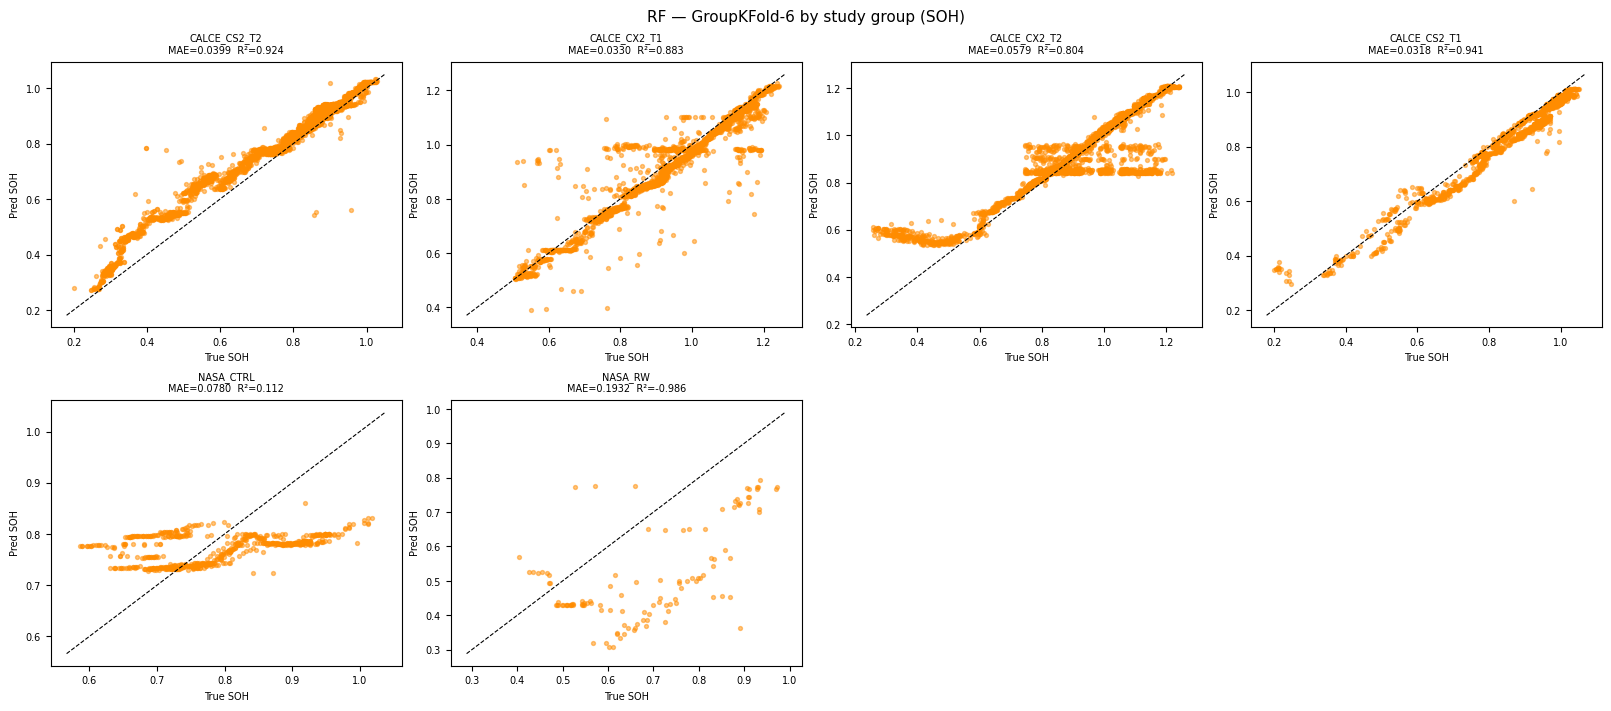

In [8]:
vgx.per_fold_scatter_ext(
    res_rf_gkf,
    "RF — GroupKFold-6 by study group (SOH)",
    save_path=RESULTS / "03_gru_rf_gkf_per_fold.png",
)

## GRU — `VGGRUReg`

Bidirectional 1-layer GRU → masked mean+max pool (4H) → Dropout → Linear.  
Architecture: `VGGRUReg(n_features=3, hidden=47, dropout=0.35)` (~14.9k params).  
GRU has 3 gates (reset, update, new) vs LSTM's 4 (input, forget, cell, output) — no cell state.

In [9]:
demo_gru = src.vg_models.VGGRUReg(n_features=3, hidden=47, dropout=0.35).to(DEVICE)
n_params_gru = sum(p.numel() for p in demo_gru.parameters())
print(f"VGGRUReg params: {n_params_gru:,}")

x4 = torch.tensor(X[:4]).to(DEVICE)
m4 = torch.tensor(mask[:4]).to(DEVICE)
with torch.no_grad():
    out4 = demo_gru(x4, m4)
print(f"Forward output shape: {out4.shape}  (expect (4,))")
del demo_gru, x4, m4, out4

VGGRUReg params: 14,853
Forward output shape: torch.Size([4])  (expect (4,))


In [ ]:
make_gru = lambda: src.vg_models.VGGRUReg(n_features=3, hidden=47, dropout=0.35)

print("GRU — GroupKFold-6 (by study group)")
res_gru_gkf = vgx.run_grouped_cv(
    make_gru, X, mask, y, groups, cidx, DEVICE,
    GroupKFold(n_splits=6),
    cv_groups=study_groups,
    epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR, patience=PATIENCE,
    scheduler="cosine",
)
agg_gru_gkf = vg.aggregate(res_gru_gkf)
print(f"\n  MAE  {agg_gru_gkf['mae']:.4f} ± {agg_gru_gkf['mae_std']:.4f}")
print(f"  RMSE {agg_gru_gkf['rmse']:.4f} ± {agg_gru_gkf['rmse_std']:.4f}")
print(f"  R²   {agg_gru_gkf['r2']:.4f} ± {agg_gru_gkf['r2_std']:.4f}")
print(f"  Skill     {agg_gru_gkf['skill']:.4f}")
print(f"  Spearman  {agg_gru_gkf['spearman']:.4f}")

GRU — GroupKFold-6 (by study group)


  0%|                    | 0/300 [00:00<?, ?ep/s]

  [ 1/6] held=CALCE_CS2_T2          val=CS2_38  MAE=0.0242  R²=0.959  best_ep=6


  0%|                    | 0/300 [00:00<?, ?ep/s]

  [ 2/6] held=CALCE_CX2_T1          val=CX2_35  MAE=0.0295  R²=0.868  best_ep=41


...

  [ 4/6] held=CALCE_CS2_T1          val=CS2_34  MAE=0.0415  R²=0.860  best_ep=5


  0%|                    | 0/300 [00:00<?, ?ep/s]

  [ 5/6] held=NASA_CTRL             val=B0018  MAE=0.0281  R²=0.860  best_ep=11


  0%|                    | 0/300 [00:00<?, ?ep/s]

  [ 6/6] held=NASA_RW               val=RW20  MAE=0.0694  R²=0.712  best_ep=12

  MAE  0.0371 ± 0.0154
  RMSE 0.0544 ± 0.0158
  R²   0.8685 ± 0.0816
  Skill     0.7584
  Spearman  0.9723


  Saved: c:\dev\ml-project\results\extended_tier1\03_gru_gkf_per_fold.png


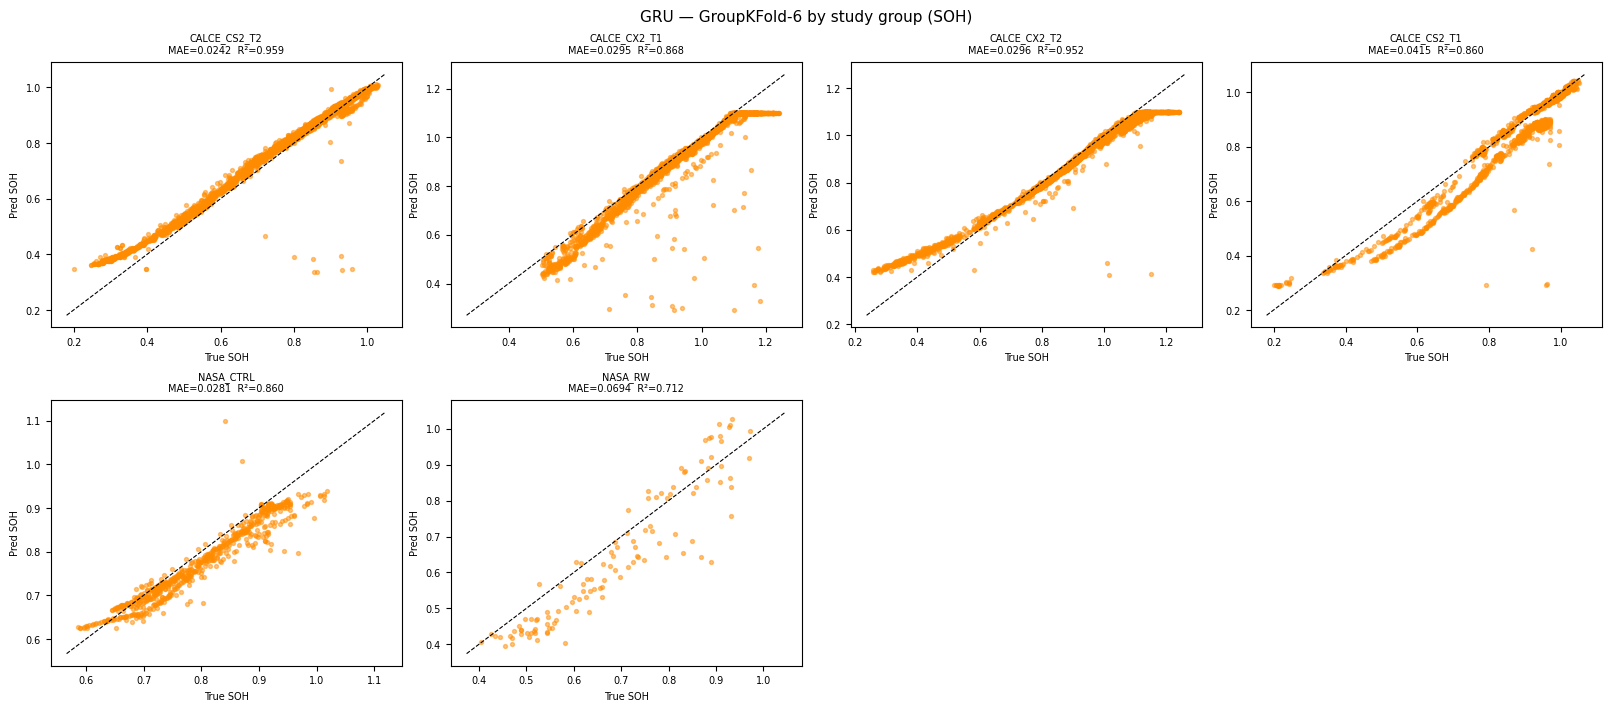

  Saved: c:\dev\ml-project\results\extended_tier1\03_gru_gkf_loss_curves.png


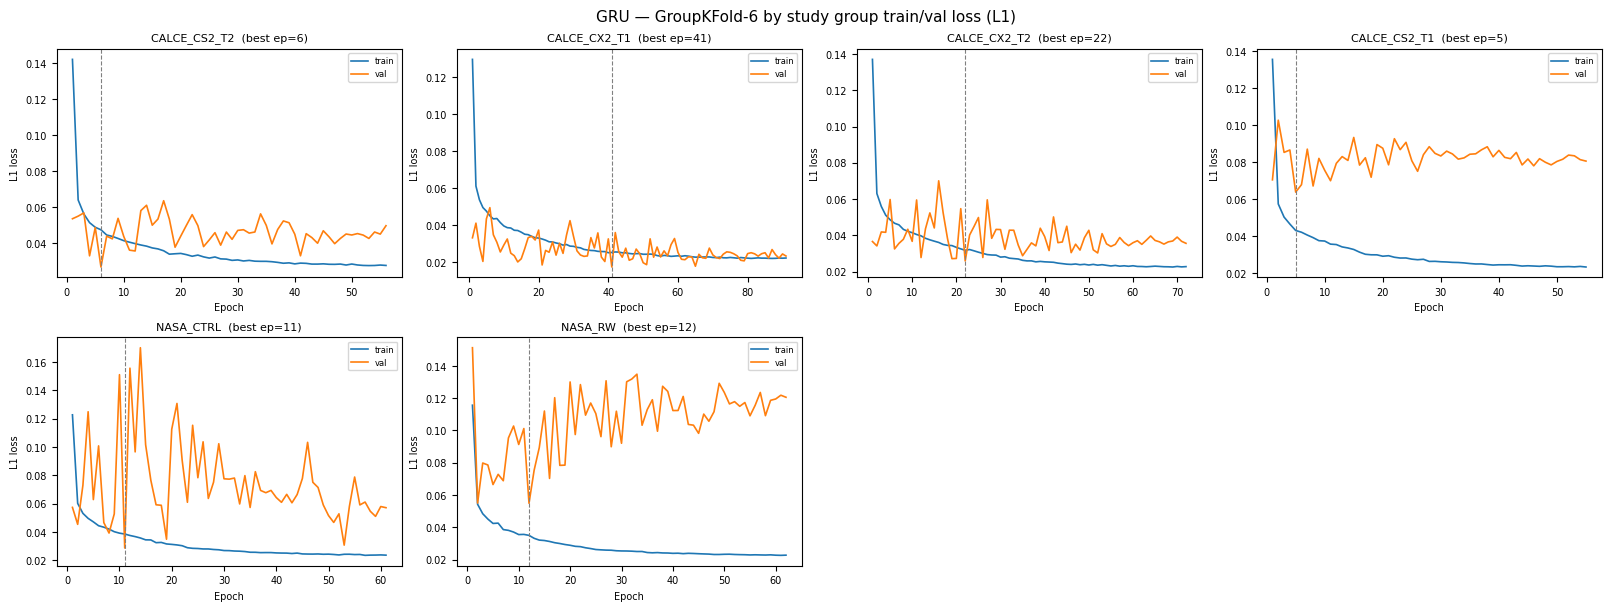

In [11]:
vgx.per_fold_scatter_ext(
    res_gru_gkf,
    "GRU — GroupKFold-6 by study group (SOH)",
    save_path=RESULTS / "03_gru_gkf_per_fold.png",
)
vgx.per_fold_loss_curves_ext(
    res_gru_gkf,
    "GRU — GroupKFold-6 by study group train/val loss (L1)",
    save_path=RESULTS / "03_gru_gkf_loss_curves.png",
)

## CNN-GRU — `VGCNNGRU`

Conv1d front-end (kernel 5, GroupNorm, same-padding) → BiGRU → masked pool → Dropout → Linear.  
Architecture: `VGCNNGRU(n_features=3, cnn_ch=8, hidden=47, dropout=0.35)` (~16.4k params).

In [ ]:
demo_cnngru = src.vg_models.VGCNNGRU(n_features=3, cnn_ch=16, hidden=47, dropout=0.35, cnn_dropout=0.1).to(DEVICE)
n_params_cnngru = sum(p.numel() for p in demo_cnngru.parameters())
print(f"VGCNNGRU params: {n_params_cnngru:,}")

x4 = torch.tensor(X[:4]).to(DEVICE)
m4 = torch.tensor(mask[:4]).to(DEVICE)
with torch.no_grad():
    out4 = demo_cnngru(x4, m4)
print(f"Forward output shape: {out4.shape}  (expect (4,))")
del demo_cnngru, x4, m4, out4

VGCNNGRU params: 16,399
Forward output shape: torch.Size([4])  (expect (4,))


In [ ]:
make_cnngru = lambda: src.vg_models.VGCNNGRU(n_features=3, cnn_ch=8, hidden=47, dropout=0.35)

print("CNN-GRU — GroupKFold-6 (by study group)")
res_cnngru_gkf = vgx.run_grouped_cv(
    make_cnngru, X, mask, y, groups, cidx, DEVICE,
    GroupKFold(n_splits=6),
    cv_groups=study_groups,
    epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR, patience=PATIENCE,
    scheduler="cosine",
)
agg_cnngru_gkf = vg.aggregate(res_cnngru_gkf)
print(f"\n  MAE  {agg_cnngru_gkf['mae']:.4f} ± {agg_cnngru_gkf['mae_std']:.4f}")
print(f"  RMSE {agg_cnngru_gkf['rmse']:.4f} ± {agg_cnngru_gkf['rmse_std']:.4f}")
print(f"  R²   {agg_cnngru_gkf['r2']:.4f} ± {agg_cnngru_gkf['r2_std']:.4f}")
print(f"  Skill     {agg_cnngru_gkf['skill']:.4f}")
print(f"  Spearman  {agg_cnngru_gkf['spearman']:.4f}")

CNN-GRU — GroupKFold-6 (by study group)


  0%|                    | 0/300 [00:00<?, ?ep/s]

  [ 1/6] held=CALCE_CS2_T2          val=CS2_38  MAE=0.0208  R²=0.958  best_ep=10


  0%|                    | 0/300 [00:00<?, ?ep/s]

  [ 2/6] held=CALCE_CX2_T1          val=CX2_35  MAE=0.0595  R²=0.773  best_ep=85


...

  [ 4/6] held=CALCE_CS2_T1          val=CS2_34  MAE=0.0834  R²=0.657  best_ep=49


  0%|                    | 0/300 [00:00<?, ?ep/s]

  [ 5/6] held=NASA_CTRL             val=B0018  MAE=0.0665  R²=0.316  best_ep=88


  0%|                    | 0/300 [00:00<?, ?ep/s]

  [ 6/6] held=NASA_RW               val=RW20  MAE=0.0689  R²=0.676  best_ep=59

  MAE  0.0596 ± 0.0192
  RMSE 0.0752 ± 0.0184
  R²   0.7130 ± 0.2082
  Skill     0.5901
  Spearman  0.9255


  Saved: c:\dev\ml-project\results\extended_tier1\03_cnngru_gkf_per_fold.png


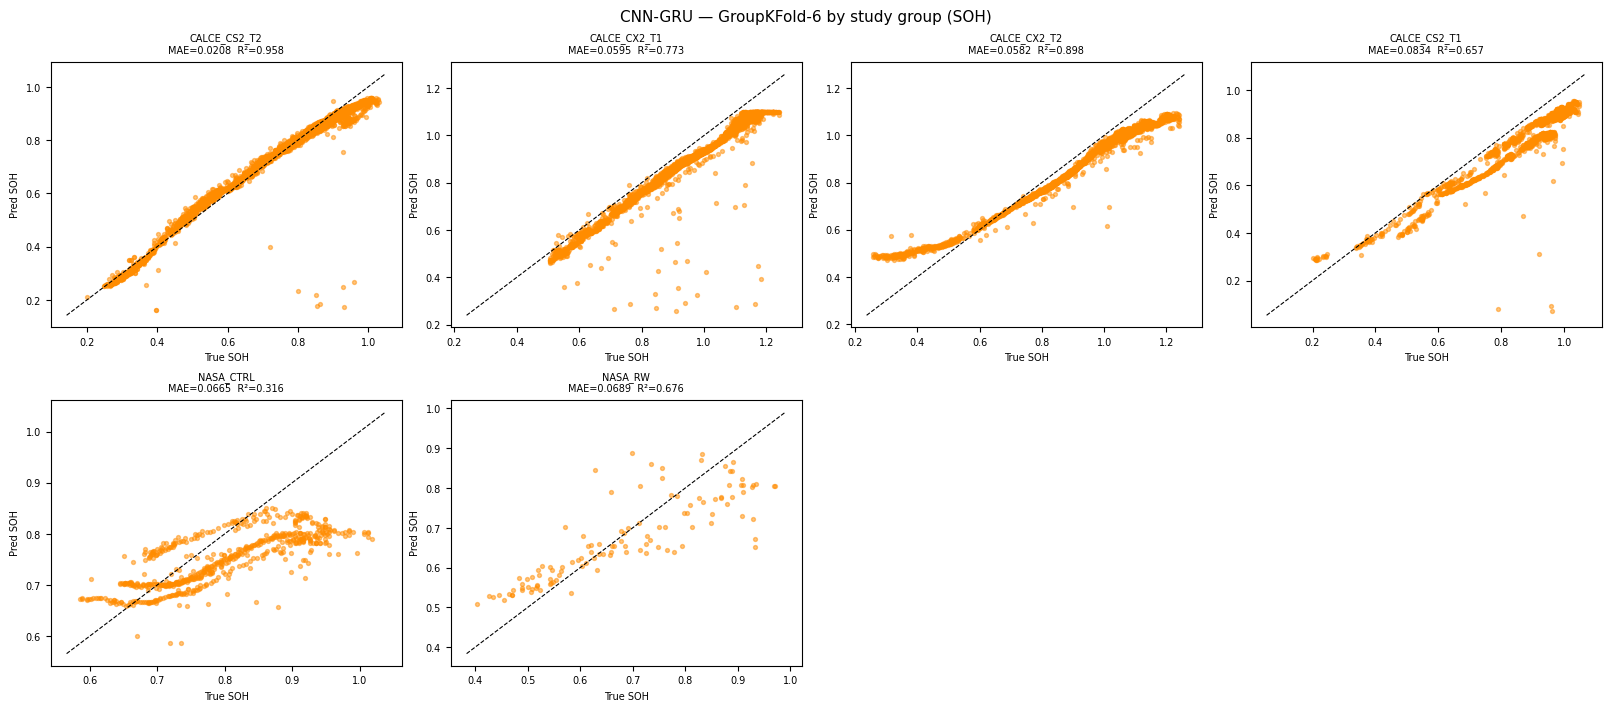

  Saved: c:\dev\ml-project\results\extended_tier1\03_cnngru_gkf_loss_curves.png


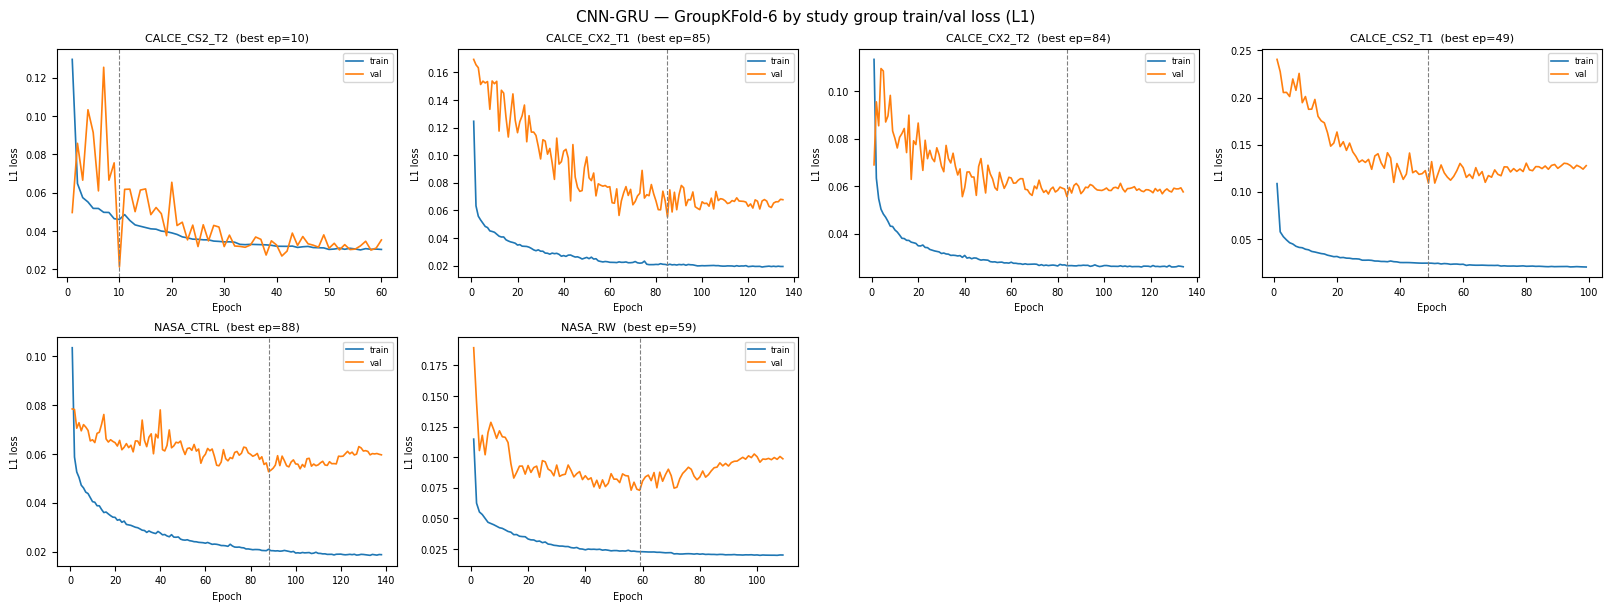

In [14]:
vgx.per_fold_scatter_ext(
    res_cnngru_gkf,
    "CNN-GRU — GroupKFold-6 by study group (SOH)",
    save_path=RESULTS / "03_cnngru_gkf_per_fold.png",
)
vgx.per_fold_loss_curves_ext(
    res_cnngru_gkf,
    "CNN-GRU — GroupKFold-6 by study group train/val loss (L1)",
    save_path=RESULTS / "03_cnngru_gkf_loss_curves.png",
)

## GroupKFold-6 comparison

In [15]:
ARM_ORDER_GKF = [
    ("RF",      res_rf_gkf,     agg_rf_gkf),
    ("GRU",     res_gru_gkf,    agg_gru_gkf),
    ("+CNNGRU", res_cnngru_gkf, agg_cnngru_gkf),
]
LOWER_BETTER = {"MAE", "RMSE"}

agg_str, agg_num = {}, {}
for arm, _, agg in ARM_ORDER_GKF:
    agg_str[arm] = {
        "MAE":      f"{agg['mae']:.4f} \u00b1 {agg['mae_std']:.4f}",
        "RMSE":     f"{agg['rmse']:.4f} \u00b1 {agg['rmse_std']:.4f}",
        "R\u00b2":       f"{agg['r2']:.4f} \u00b1 {agg['r2_std']:.4f}",
        "Skill":    f"{agg['skill']:.4f}",
        "Spearman": f"{agg['spearman']:.4f}",
    }
    agg_num[arm] = {
        "MAE":      agg["mae"],
        "RMSE":     agg["rmse"],
        "R\u00b2":       agg["r2"],
        "Skill":    agg["skill"],
        "Spearman": agg["spearman"],
    }

df_str = pd.DataFrame(agg_str).T
df_num = pd.DataFrame(agg_num).T

def _bold_better(df_display, df_values, lower_better):
    styled = df_display.copy()
    for col in df_display.columns:
        if col in lower_better:
            best_idx = df_values[col].idxmin()
        else:
            best_idx = df_values[col].idxmax()
        styled.loc[best_idx, col] = f"**{df_display.loc[best_idx, col]}**"
    return styled

df_display = _bold_better(df_str, df_num, LOWER_BETTER)
print("=== GroupKFold-6 aggregate results ===")
display(df_display)

df_str.to_csv(RESULTS / "03_gru_comparison_gkf_metrics.csv")
print(f"Saved: {RESULTS / '03_gru_comparison_gkf_metrics.csv'}")

fold_rows = []
for arm, res, _ in ARM_ORDER_GKF:
    for fi, fold in enumerate(res):
        m = fold["metrics"]
        fold_rows.append({
            "Model":      arm,
            "Fold":       fi + 1,
            "HeldGroup":  ",".join(fold.get("held_group") or []),
            "HeldBids":   ",".join(fold.get("held_bids") or []),
            "MAE":        m["mae"],
            "RMSE":       m["rmse"],
            "R\u00b2":         m["r2"],
            "Skill":      m["skill"],
            "Spearman":   m["spearman"],
            "best_ep":    fold.get("best_epoch"),
        })

df_folds = pd.DataFrame(fold_rows)
df_pivot = df_folds.pivot_table(
    index=["Fold", "HeldGroup", "HeldBids"],
    columns="Model",
    values=["MAE", "RMSE", "R\u00b2", "Skill", "Spearman", "best_ep"],
).round(4)

print("\n=== Per-fold breakdown ===")
display(df_pivot)
df_pivot.to_csv(RESULTS / "03_gru_per_fold_gkf_metrics.csv")
print(f"Saved: {RESULTS / '03_gru_per_fold_gkf_metrics.csv'}")

=== GroupKFold-6 aggregate results ===


,MAE,RMSE,R²,Skill,Spearman
RF,0.0723 ± 0.0564,0.0922 ± 0.0595,0.4464 ± 0.7018,0.5384,0.7765
GRU,**0.0371 ± 0.0154**,**0.0544 ± 0.0158**,**0.8685 ± 0.0816**,**0.7584**,**0.9723**
+CNNGRU,0.0596 ± 0.0192,0.0752 ± 0.0184,0.7130 ± 0.2082,0.5901,0.9255


Saved: c:\dev\ml-project\results\extended_tier1\03_gru_comparison_gkf_metrics.csv

=== Per-fold breakdown ===


MAE          \
Model                                                    +CNNGRU     GRU   
Fold HeldGroup    HeldBids                                                 
1    CALCE_CS2_T2 CS2_35,CS2_36,CS2_37,CS2_38             0.0208  0.0242   
2    CALCE_CX2_T1 CX2_33,CX2_35                           0.0595  0.0295   
3    CALCE_CX2_T2 CX2_37,CX2_38                           0.0582  0.0296   
4    CALCE_CS2_T1 CS2_33,CS2_34                           0.0834  0.0415   
5    NASA_CTRL    B0005,B0006,B0007,B0018                 0.0665  0.0281   
6    NASA_RW      RW1,RW13,RW14,RW15,RW16,RW17,RW19,RW20  0.0689  0.0694   

                                                                    RMSE  \
Model                                                         RF +CNNGRU   
Fold HeldGroup    HeldBids                                                 
1    CALCE_CS2_T2 CS2_35,CS2_36,CS2_37,CS2_38             0.0399  0.0394   
2    CALCE_CX2_T1 CX2_33,CX2_35                           0.0330  0.0758   
3    CALCE_CX2_T2 CX2_37,CX2_38                           0.0579  0.0692   
4    CALCE_CS2_T1 CS2_33,CS2_34                           0.0318  0.0982   
5    NASA_CTRL    B0005,B0006,B0007,B0018                 0.0780  0.0813   
6    NASA_RW      RW1,RW13,RW14,RW15,RW16,RW17,RW19,RW20  0.1932  0.0876   

                                                                          \
Model                                                        GRU      RF   
Fold HeldGroup    HeldBids                                                 
1    CALCE_CS2_T2 CS2_35,CS2_36,CS2_37,CS2_38             0.0387  0.0528   
2    CALCE_CX2_T1 CX2_33,CX2_35                           0.0577  0.0545   
3    CALCE_CX2_T2 CX2_37,CX2_38                           0.0475  0.0959   
4    CALCE_CS2_T1 CS2_33,CS2_34                           0.0629  0.0406   
5    NASA_CTRL    B0005,B0006,B0007,B0018                 0.0367  0.0925   
6    NASA_RW      RW1,RW13,RW14,RW15,RW16,RW17,RW19,RW20  0.0826  0.2169   

                                                              R²          \
Model                                                    +CNNGRU     GRU   
Fold HeldGroup    HeldBids                                                 
1    CALCE_CS2_T2 CS2_35,CS2_36,CS2_37,CS2_38             0.9576  0.9593   
2    CALCE_CX2_T1 CX2_33,CX2_35                           0.7730  0.8685   
3    CALCE_CX2_T2 CX2_37,CX2_38                           0.8981  0.9520   
4    CALCE_CS2_T1 CS2_33,CS2_34                           0.6574  0.8595   
5    NASA_CTRL    B0005,B0006,B0007,B0018                 0.3156  0.8602   
6    NASA_RW      RW1,RW13,RW14,RW15,RW16,RW17,RW19,RW20  0.6761  0.7118   

                                                                   Skill  \
Model                                                         RF +CNNGRU   
Fold HeldGroup    HeldBids                                                 
1    CALCE_CS2_T2 CS2_35,CS2_36,CS2_37,CS2_38             0.9241  0.8592   
2    CALCE_CX2_T1 CX2_33,CX2_35                           0.8826  0.6513   
3    CALCE_CX2_T2 CX2_37,CX2_38                           0.8039  0.6832   
4    CALCE_CS2_T1 CS2_33,CS2_34                           0.9414  0.3464   
5    NASA_CTRL    B0005,B0006,B0007,B0018                 0.1124  0.3496   
6    NASA_RW      RW1,RW13,RW14,RW15,RW16,RW17,RW19,RW20 -0.9860  0.6510   

                                                                          \
Model                                                        GRU      RF   
Fold HeldGroup    HeldBids                                                 
1    CALCE_CS2_T2 CS2_35,CS2_36,CS2_37,CS2_38             0.8363  0.7305   
2    CALCE_CX2_T1 CX2_33,CX2_35                           0.8269  0.8066   
3    CALCE_CX2_T2 CX2_37,CX2_38                           0.8388  0.6850   
4    CALCE_CS2_T1 CS2_33,CS2_34                           0.6751  0.7505   
5    NASA_CTRL    B0005,B0006,B0007,B0018                 0.7249  0.2369   
6    NASA_RW      RW1,RW13,R

Saved: c:\dev\ml-project\results\extended_tier1\03_gru_per_fold_gkf_metrics.csv


## Leave-One-Dataset-Out (NASA ↔ CALCE transfer)

Two folds only:
- **hold-NASA**: train on CALCE, test on NASA
- **hold-CALCE**: train on NASA, test on CALCE

This reveals how well the voltage-grid representation generalises across cell chemistries / cycler protocols.

In [16]:
print("RF \u2014 LODO")
res_rf_lodo = vgx.run_rf_grouped_cv(
    feat, y, groups, cidx,
    LeaveOneGroupOut(),
    cv_groups=ds_groups,
)
agg_rf_lodo = vg.aggregate(res_rf_lodo)
print(f"  MAE {agg_rf_lodo['mae']:.4f}  R\u00b2 {agg_rf_lodo['r2']:.4f}")

RF — LODO
  [ 1/2] held=calce                 MAE=0.1414  R²=0.254
  [ 2/2] held=nasa                  MAE=0.1524  R²=-1.022
  MAE 0.1469  R² -0.3839


In [ ]:
print("GRU \u2014 LODO")
res_gru_lodo = vgx.run_grouped_cv(
    make_gru, X, mask, y, groups, cidx, DEVICE,
    LeaveOneGroupOut(),
    cv_groups=ds_groups,
    epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR, patience=PATIENCE,
    scheduler="cosine",
)
agg_gru_lodo = vg.aggregate(res_gru_lodo)
print(f"  MAE {agg_gru_lodo['mae']:.4f}  R\u00b2 {agg_gru_lodo['r2']:.4f}")

GRU — LODO


  0%|                    | 0/300 [00:00<?, ?ep/s]

  [ 1/2] held=calce                 val=CX2_38  MAE=0.0395  R²=0.921  best_ep=52


  0%|                    | 0/300 [00:00<?, ?ep/s]

  [ 2/2] held=nasa                  val=RW20  MAE=0.0348  R²=0.850  best_ep=11
  MAE 0.0371  R² 0.8857


In [ ]:
print("CNN-GRU \u2014 LODO")
res_cnngru_lodo = vgx.run_grouped_cv(
    make_cnngru, X, mask, y, groups, cidx, DEVICE,
    LeaveOneGroupOut(),
    cv_groups=ds_groups,
    epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR, patience=PATIENCE,
    scheduler="cosine",
)
agg_cnngru_lodo = vg.aggregate(res_cnngru_lodo)
print(f"  MAE {agg_cnngru_lodo['mae']:.4f}  R\u00b2 {agg_cnngru_lodo['r2']:.4f}")

CNN-GRU — LODO


  0%|                    | 0/300 [00:00<?, ?ep/s]

  [ 1/2] held=calce                 val=CX2_38  MAE=0.1727  R²=0.065  best_ep=26


  0%|                    | 0/300 [00:00<?, ?ep/s]

  [ 2/2] held=nasa                  val=RW20  MAE=0.0955  R²=-0.286  best_ep=1
  MAE 0.1341  R² -0.1105


=== Leave-One-Dataset-Out results ===


MAE                    RMSE                      R²          \
Model             RF     GRU +CNNGRU      RF     GRU +CNNGRU      RF     GRU   
Held dataset                                                                   
calce         0.1414  0.0395  0.1727  0.1729  0.0561  0.1936  0.2542  0.9214   
nasa          0.1524  0.0348  0.0955  0.1648  0.0449  0.1314 -1.0219  0.8501   

                       Skill                  
Model        +CNNGRU      RF     GRU +CNNGRU  
Held dataset                                  
calce         0.0648  0.2349  0.7862  0.0657  
nasa         -0.2857 -0.2917  0.7052  0.1909

Saved: c:\dev\ml-project\results\extended_tier1\03_gru_comparison_lodo_metrics.csv
  Saved: c:\dev\ml-project\results\extended_tier1\03_rf_lodo_per_fold.png


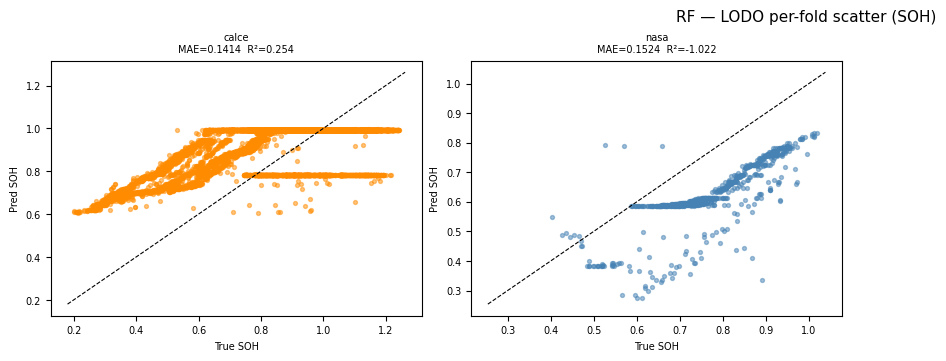

  Saved: c:\dev\ml-project\results\extended_tier1\03_gru_lodo_per_fold.png


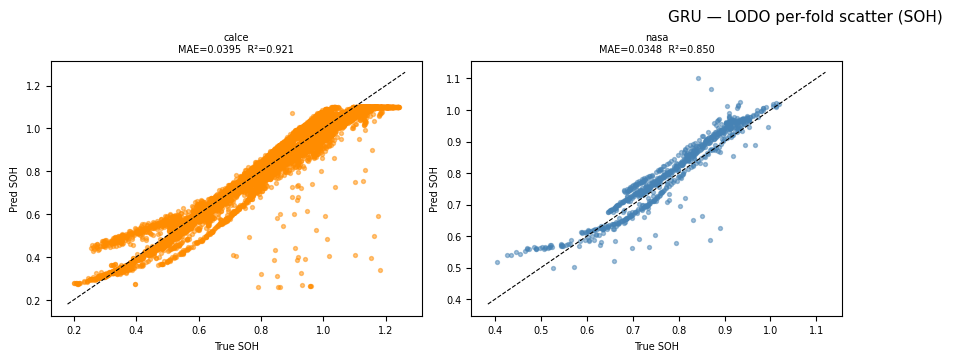

  Saved: c:\dev\ml-project\results\extended_tier1\03_cnncnngru_lodo_per_fold.png


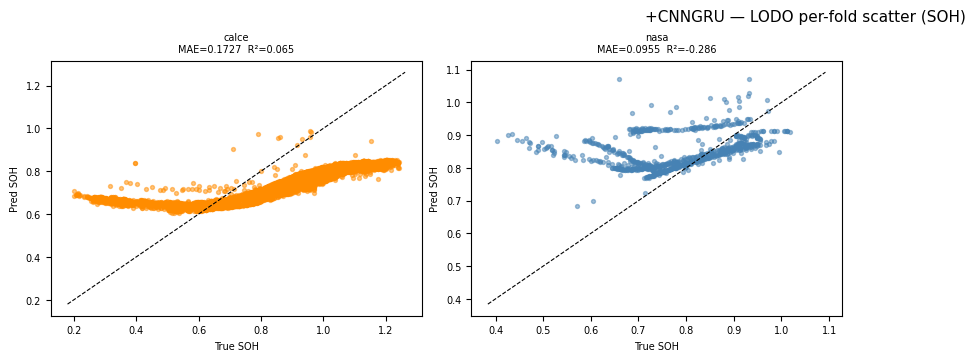

In [19]:
ARM_ORDER_LODO = [
    ("RF",      res_rf_lodo,     agg_rf_lodo),
    ("GRU",     res_gru_lodo,    agg_gru_lodo),
    ("+CNNGRU", res_cnngru_lodo, agg_cnngru_lodo),
]

lodo_rows = []
for arm, res, _ in ARM_ORDER_LODO:
    for fold in res:
        m = fold["metrics"]
        held_ds = ",".join(fold.get("held_group") or [])
        lodo_rows.append({
            "Model":        arm,
            "Held dataset": held_ds,
            "MAE":          round(m["mae"],  4),
            "RMSE":         round(m["rmse"], 4),
            "R\u00b2":           round(m["r2"],   4),
            "Skill":        round(m["skill"], 4),
            "Spearman":     round(m["spearman"], 4),
            "n":            m["n"],
        })

df_lodo = pd.DataFrame(lodo_rows)
print("=== Leave-One-Dataset-Out results ===")
display(df_lodo.pivot_table(index="Held dataset", columns="Model",
                             values=["MAE", "RMSE", "R\u00b2", "Skill"], sort=False).round(4))

df_lodo.to_csv(RESULTS / "03_gru_comparison_lodo_metrics.csv", index=False)
print(f"Saved: {RESULTS / '03_gru_comparison_lodo_metrics.csv'}")

for arm, res, _ in ARM_ORDER_LODO:
    vgx.per_fold_scatter_ext(
        res,
        f"{arm} \u2014 LODO per-fold scatter (SOH)",
        save_path=RESULTS / f"03_{arm.lower().replace('+', 'cnn')}_lodo_per_fold.png",
    )

## Conclusion

Fill in after running:

- **GRU vs LSTM (GroupKFold-6):** does GRU match, beat, or trail LSTM? GRU typically trains faster (fewer params per step) and can generalise better on smaller datasets by avoiding over-parameterisation of the gating mechanism.
- **CNN-GRU vs CNN-LSTM:** does the CNN front-end benefit GRU the same way it did (or didn't) for LSTM?
- **LODO transfer:** compare GRU LODO gap (GroupKFold-6 MAE − LODO MAE) to LSTM's gap from notebook 02. A smaller gap suggests GRU learns a more chemistry-agnostic representation.
- **Key slide:** GRU vs LSTM comparison table. If GRU matches LSTM with fewer params per hidden unit, it is the preferred model for deployment (lower inference cost on embedded systems).